# Task 5: Logistic Regression – Bank Customer Churn Prediction

## Objective

The objective of this project is to develop a Logistic Regression model to predict whether a bank customer will churn based on customer demographic, financial, and account-related characteristics.

## Domain

Banking and Financial Services

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("../dataset/Bank Customer Churn Prediction.csv")

df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.shape

(10000, 12)

In [6]:
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


In [8]:
df.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [11]:
df["churn"].value_counts()

churn
0    7963
1    2037
Name: count, dtype: int64

In [12]:
df["churn"].value_counts(normalize=True) * 100

churn
0    79.63
1    20.37
Name: proportion, dtype: float64

## 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the distribution of customer churn and identify the demographic, financial, and account-related factors associated with customer churn.

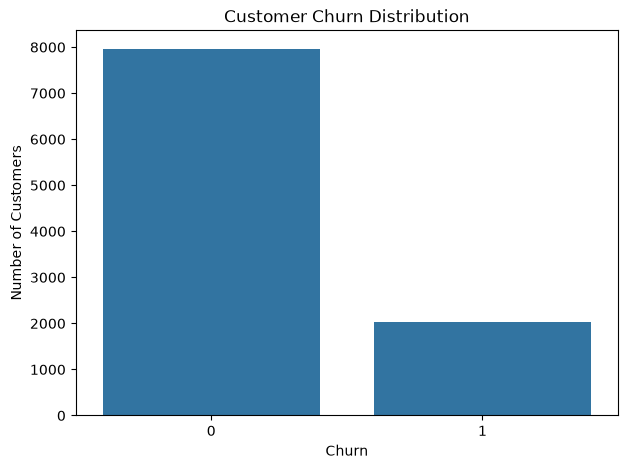

In [13]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [14]:
churn_percent = df["churn"].value_counts(normalize=True) * 100

print(churn_percent)

churn
0    79.63
1    20.37
Name: proportion, dtype: float64


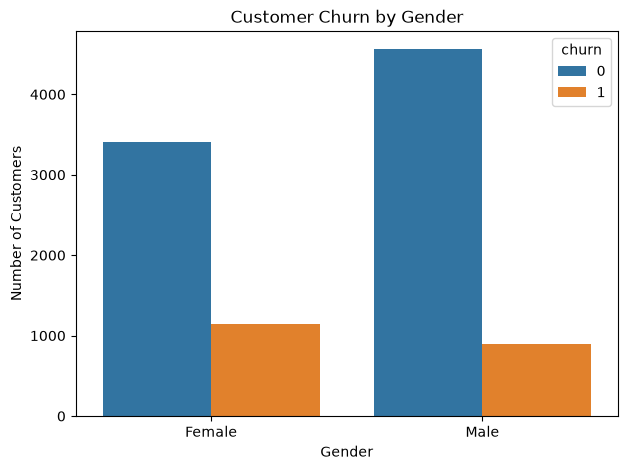

In [15]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="gender", hue="churn")

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

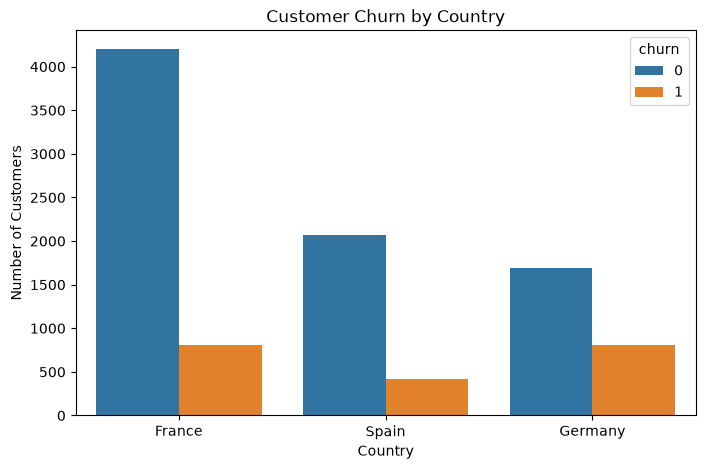

In [16]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="country", hue="churn")

plt.title("Customer Churn by Country")
plt.xlabel("Country")
plt.ylabel("Number of Customers")

plt.show()

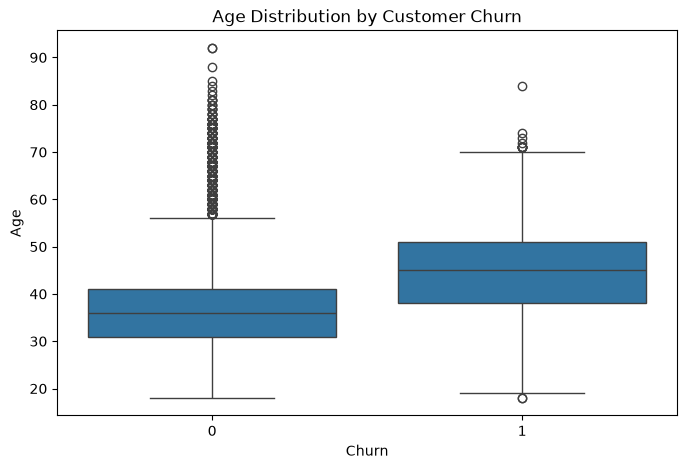

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="churn", y="age")

plt.title("Age Distribution by Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Age")

plt.show()

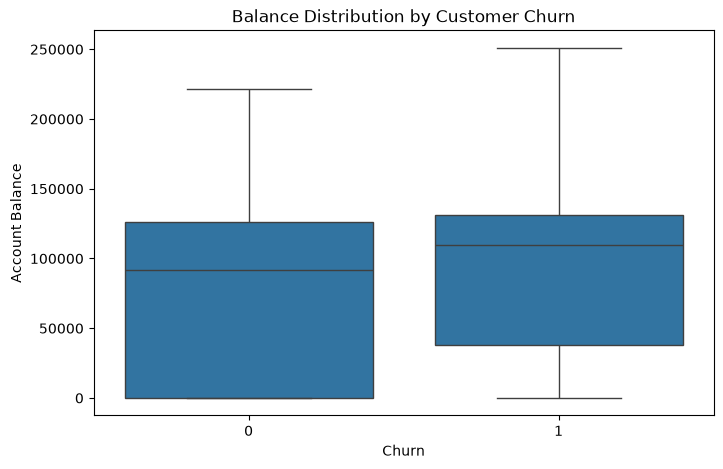

In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="churn", y="balance")

plt.title("Balance Distribution by Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Account Balance")

plt.show()

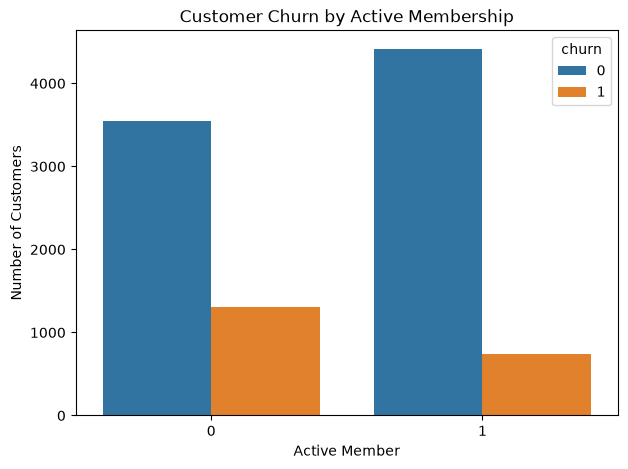

In [19]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="active_member", hue="churn")

plt.title("Customer Churn by Active Membership")
plt.xlabel("Active Member")
plt.ylabel("Number of Customers")

plt.show()

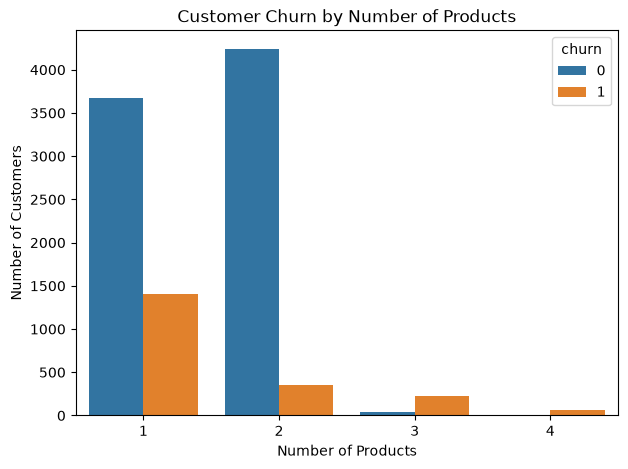

In [20]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="products_number", hue="churn")

plt.title("Customer Churn by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Number of Customers")

plt.show()

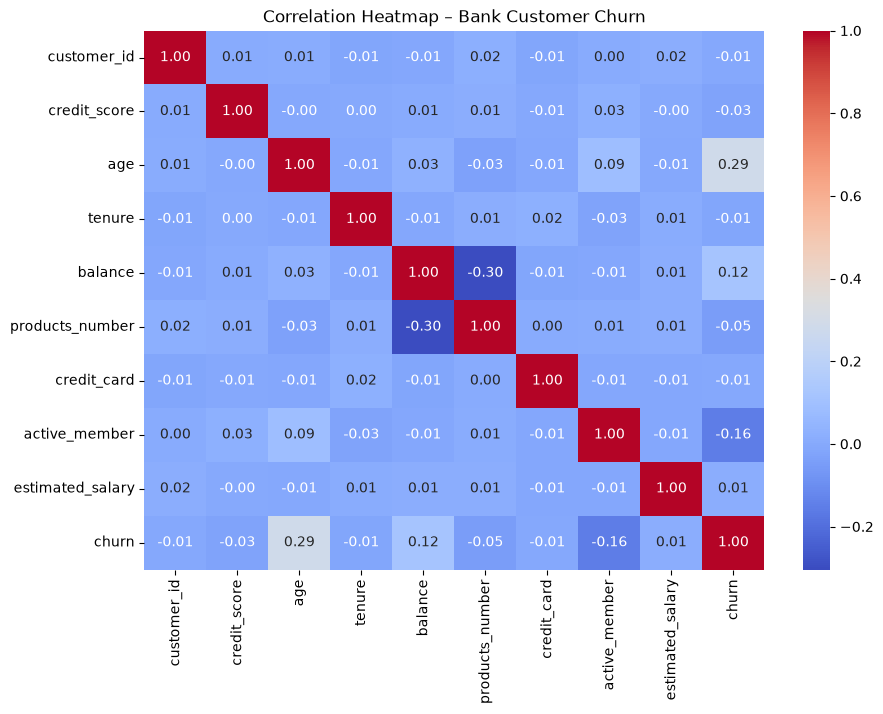

In [21]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap – Bank Customer Churn")
plt.show()

In [22]:
print(df["churn"].unique())

[1 0]


In [23]:
features = [
    "credit_score",
    "country",
    "gender",
    "age",
    "tenure",
    "balance",
    "products_number",
    "credit_card",
    "active_member",
    "estimated_salary"
]

X = df[features]
y = df["churn"]

In [24]:
X = pd.get_dummies(
    X,
    columns=["country", "gender"],
    drop_first=True
)

In [25]:
X.head()

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,country_Germany,country_Spain,gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


In [26]:
print("Number of features after encoding:", X.shape[1])

Number of features after encoding: 11


## Train-Test Split

The dataset is divided into training and testing sets. The training data is used to train the Logistic Regression model, while the testing data is used to evaluate its performance on unseen customer records.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [28]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (8000, 11)
Testing features: (2000, 11)
Training target: (8000,)
Testing target: (2000,)


In [29]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression Model

Logistic Regression is used because the target variable, customer churn, is binary. The model predicts whether a customer is likely to churn (1) or remain with the bank (0).

In [30]:
model = LogisticRegression(random_state=42)

model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [31]:
y_pred = model.predict(X_test_scaled)

In [32]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [33]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.808
Precision: 0.5891472868217055
Recall   : 0.18673218673218672
F1 Score : 0.2835820895522388
ROC-AUC  : 0.7747778595236223


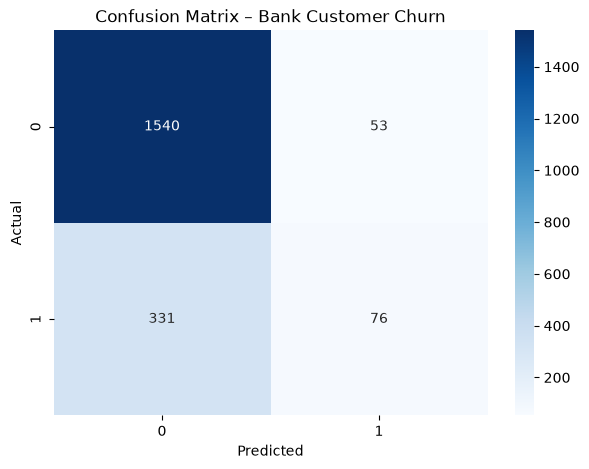

In [34]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix – Bank Customer Churn")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [35]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



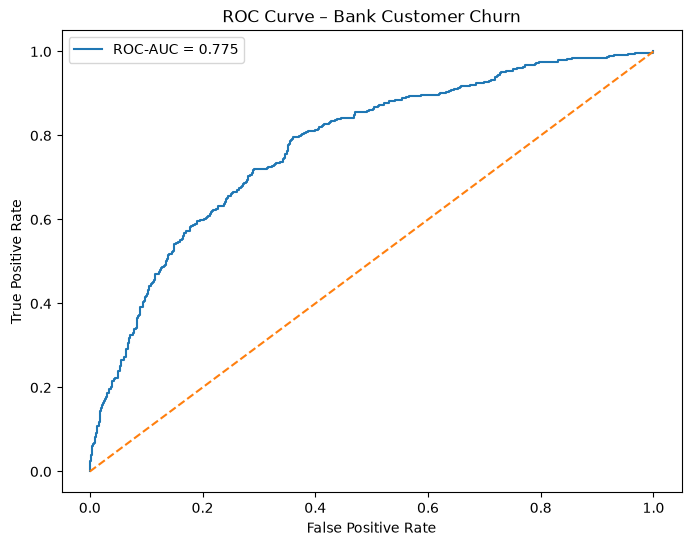

In [36]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Bank Customer Churn")
plt.legend()

plt.show()

In [37]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute_Coefficient"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient,Absolute_Coefficient
1,age,0.738847,0.738847
6,active_member,-0.515485,0.515485
8,country_Germany,0.356679,0.356679
10,gender_Male,-0.260851,0.260851
3,balance,0.160622,0.160622
0,credit_score,-0.085986,0.085986
4,products_number,-0.070292,0.070292
7,estimated_salary,0.047725,0.047725
5,credit_card,-0.032208,0.032208
2,tenure,-0.020071,0.020071


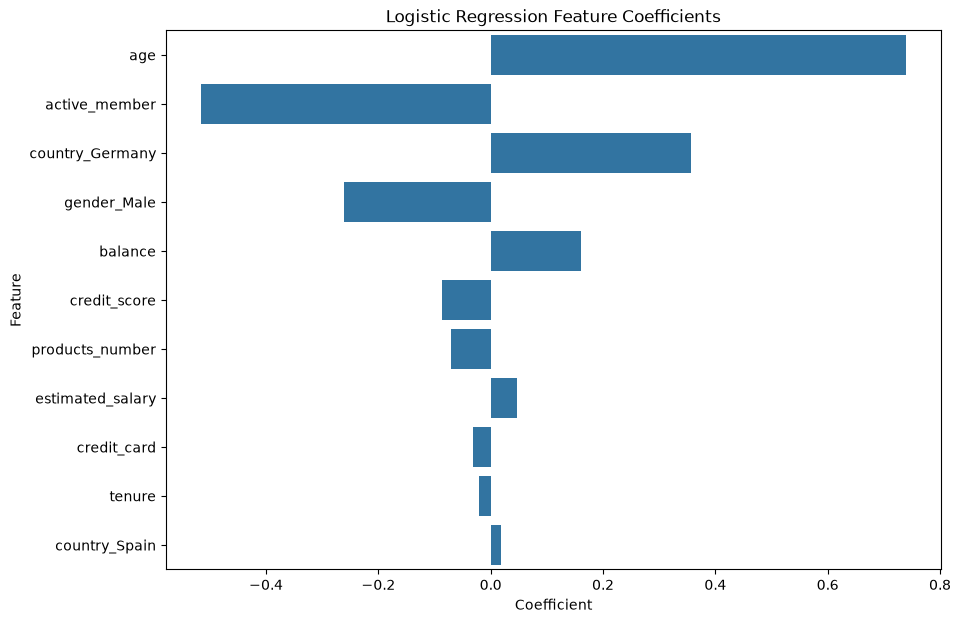

In [38]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

In [39]:
print("Actual churn counts:")
print(y_test.value_counts())

print("\nPredicted churn counts:")
print(pd.Series(y_pred).value_counts())

Actual churn counts:
churn
0    1593
1     407
Name: count, dtype: int64

Predicted churn counts:
0    1871
1     129
Name: count, dtype: int64
